# Méthode 2 — Détection de la cataracte par YOLOv5
**Mini Projet — Vidéo Biomédicale · Master BIAM 2025/2026**

| | |
|---|---|
| **Dataset** | cataract-eye-detection v2 (Roboflow) |
| **Classes** | 0 = sain · 1 = cataracte |
| **Méthode** | YOLOv5s (fine-tuning sur poids COCO) |
| **Environnement** | Kaggle Notebook · GPU T4 |

### Pipeline
```
Roboflow API → Dataset YOLO format
      ↓
YOLOv5 clone + dépendances
      ↓
Fine-tuning yolov5s.pt (transfer learning)
      ↓
Évaluation : mAP · Précision · Rappel
      ↓
Inférence + visualisation
      ↓
Comparaison finale HOG+SVM vs YOLO
```

> **Avant de lancer** : active le GPU dans Kaggle
> Settings (icône droite) → Accelerator → **GPU T4 x1**

---
## Cellule 1 — Vérification du GPU

In [1]:
import torch

print(f'PyTorch version : {torch.__version__}')
print(f'GPU disponible  : {torch.cuda.is_available()}')

if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠ Pas de GPU — active le GPU dans Settings → Accelerator')

PyTorch version : 2.10.0+cu128
GPU disponible  : True
GPU             : Tesla T4
VRAM            : 15.6 GB


---
## Cellule 2 — Installation de YOLOv5 et Roboflow

In [2]:
# Cloner YOLOv5
!git clone https://github.com/ultralytics/yolov5.git
%cd yolov5

# Dépendances YOLOv5
!pip install -r requirements.txt -q

# Roboflow
!pip install roboflow -q

print('Installation terminée.')

Cloning into 'yolov5'...
remote: Enumerating objects: 17889, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 17889 (delta 24), reused 3 (delta 0), pack-reused 17847 (from 4)
Receiving objects: 100% (17889/17889), 17.03 MiB | 27.51 MiB/s, done.
Resolving deltas: 100% (12179/12179), done.
/kaggle/working/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 9.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

---
## Cellule 3 — Téléchargement du dataset via Roboflow

In [3]:
import sys, os
sys.path.insert(0, '/kaggle/working/yolov5')

# ── Option A : clé depuis Secrets Kaggle (recommandé) ───────────────────────
try:
    from kaggle_secrets import UserSecretsClient
    api_key = UserSecretsClient().get_secret('ROBOFLOW_API_KEY')
    print('Clé API chargée depuis les Secrets Kaggle.')
except Exception:
    # ── Option B : clé directe (si pas de Secrets configurés) ───────────────
    api_key = 'COLLE_TON_API_KEY_ICI'
    print('Clé API chargée depuis le code (pense à configurer les Secrets).')


from roboflow import Roboflow

rf      = Roboflow(api_key=api_key)
project = rf.workspace('jaouads-workspace').project('cataract-eye-detection')
version = project.version(4)
dataset = version.download('yolov5')

DATASET_PATH = dataset.location
print(f'Dataset téléchargé dans : {DATASET_PATH}')

Clé API chargée depuis les Secrets Kaggle.
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to cataract-eye-detection-4 in yolov5pytorch:: 100%|██████████| 9463/9463 [00:00<00:00, 10321.67it/s]

Dataset téléchargé dans : /kaggle/working/yolov5/cataract-eye-detection-4


---
## Cellule 4 — Correction du data.yaml

In [4]:
import yaml
from pathlib import Path

yaml_path = Path(DATASET_PATH) / 'data.yaml'

with open(yaml_path) as f:
    data_cfg = yaml.safe_load(f)

# Chemins absolus (obligatoire sur Kaggle)
data_cfg['train'] = str(Path(DATASET_PATH) / 'train' / 'images')
data_cfg['val']   = str(Path(DATASET_PATH) / 'valid' / 'images')
data_cfg['test']  = str(Path(DATASET_PATH) / 'test'  / 'images')

# Noms lisibles
data_cfg['names'] = ['sain', 'cataracte']
data_cfg['nc']    = 2

with open(yaml_path, 'w') as f:
    yaml.dump(data_cfg, f, default_flow_style=False)

print('data.yaml corrigé :')
print(yaml.dump(data_cfg, default_flow_style=False))

# Vérification des splits
for split in ['train', 'valid', 'test']:
    img_dir = Path(DATASET_PATH) / split / 'images'
    n = len(list(img_dir.glob('*.jpg'))) + len(list(img_dir.glob('*.png')))
    print(f'  {split:6s} : {n} images')

data.yaml corrigé :
names:
- sain
- cataracte
nc: 2
roboflow:
  license: CC BY 4.0
  project: cataract-eye-detection
  url: https://universe.roboflow.com/jaouads-workspace/cataract-eye-detection/dataset/4
  version: 4
  workspace: jaouads-workspace
test: /kaggle/working/yolov5/cataract-eye-detection-4/test/images
train: /kaggle/working/yolov5/cataract-eye-detection-4/train/images
val: /kaggle/working/yolov5/cataract-eye-detection-4/valid/images

  train  : 4135 images
  valid  : 396 images
  test   : 198 images


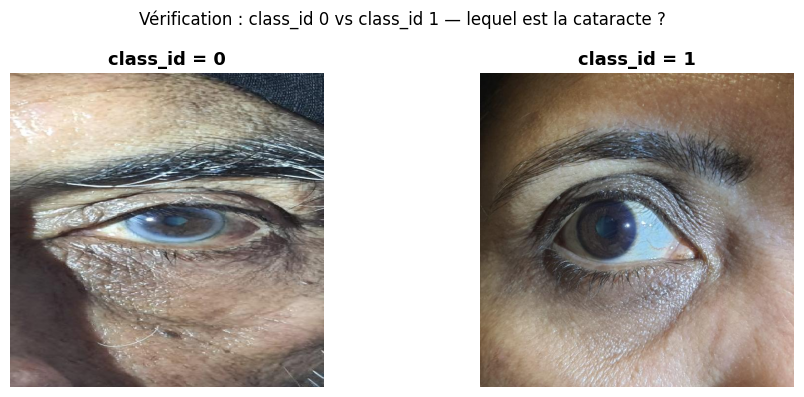

In [5]:
# Vérification : ouvrir quelques .txt et regarder quel class_id
# correspond visuellement aux yeux malades vs sains

from pathlib import Path
import cv2, matplotlib.pyplot as plt

img_dir = Path(DATASET_PATH) / 'train' / 'images'
lbl_dir = Path(DATASET_PATH) / 'train' / 'labels'

# Trouver une image avec class_id = 0 et une avec class_id = 1
exemples = {0: None, 1: None}

for lbl_path in sorted(lbl_dir.glob('*.txt')):
    with open(lbl_path) as f:
        for line in f:
            cls_id = int(line.strip().split()[0])
            if exemples[cls_id] is None:
                img_path = img_dir / (lbl_path.stem + '.jpg')
                if img_path.exists():
                    exemples[cls_id] = (img_path, lbl_path)
    if all(v is not None for v in exemples.values()):
        break

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Vérification : class_id 0 vs class_id 1 — lequel est la cataracte ?')

for cls_id, (img_path, lbl_path) in exemples.items():
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    axes[cls_id].imshow(img)
    axes[cls_id].set_title(f'class_id = {cls_id}', fontsize=13, fontweight='bold')
    axes[cls_id].axis('off')

plt.tight_layout()
plt.show()
# → Regarde quelle image est la cataracte (œil trouble/blanc)
# → Si class_id=0 est la cataracte → names = ['cataracte', 'sain']
# → Si class_id=1 est la cataracte → names = ['sain', 'cataracte']  (original)

---
## Cellule 5 — Visualisation des annotations du dataset

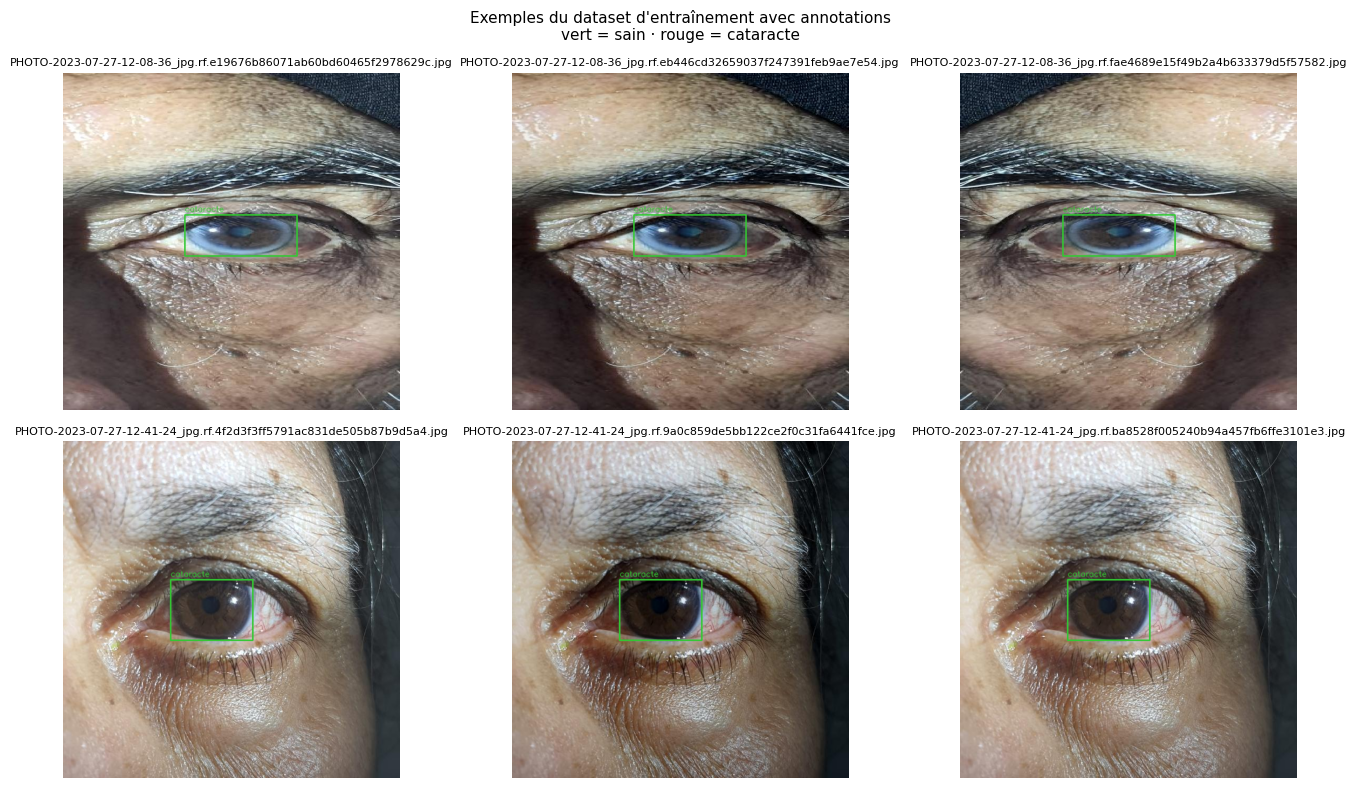

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

CLASS_NAMES = ['cataracte', 'sain']
COLORS      = [(50, 200, 50), (220, 50, 50)]

def draw_yolo_annotations(img_path, lbl_path):
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w    = img.shape[:2]
    if Path(lbl_path).exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls_id = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:])
                x1 = max(0, int((xc - bw/2) * w))
                y1 = max(0, int((yc - bh/2) * h))
                x2 = min(w, int((xc + bw/2) * w))
                y2 = min(h, int((yc + bh/2) * h))
                color = COLORS[cls_id] if cls_id < 2 else (200, 200, 0)
                cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, 2)
                cv2.putText(img_rgb, CLASS_NAMES[cls_id], (x1, max(y1-6, 12)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)
    return img_rgb

train_imgs = sorted(Path(DATASET_PATH + '/train/images').glob('*.jpg'))[:6]
if not train_imgs:
    train_imgs = sorted(Path(DATASET_PATH + '/train/images').glob('*.png'))[:6]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Exemples du dataset d'entraînement avec annotations\n"
             "vert = sain · rouge = cataracte", fontsize=11)

for ax, img_path in zip(axes.flatten(), train_imgs):
    lbl_path = Path(DATASET_PATH + '/train/labels') / (img_path.stem + '.txt')
    result   = draw_yolo_annotations(img_path, lbl_path)
    if result is not None:
        ax.imshow(result)
    ax.set_title(img_path.name, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('dataset_visualisation.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Cellule 6 — Entraînement YOLOv5

| Paramètre | Valeur | Rôle |
|---|---|---|
| `--weights` | `yolov5s.pt` | Transfer learning depuis COCO |
| `--img` | `640` | Résolution identique au dataset |
| `--batch` | `16` | Adapté au GPU T4 (16 Go VRAM) |
| `--epochs` | `50` | Nombre d'itérations complètes |
| `--patience` | `10` | Early stopping si plateau |
| `--cache` | | Mise en cache des images → plus rapide |

In [7]:
import time

t_train_start = time.time()

!python /kaggle/working/yolov5/train.py \
    --weights yolov5s.pt \
    --img 640 \
    --batch 16 \
    --epochs 50 \
    --data {yaml_path} \
    --name cataract_yolov5 \
    --patience 10 \
    --exist-ok \
    --cache

yolo_train_time = time.time() - t_train_start
BEST_WEIGHTS    = '/kaggle/working/yolov5/runs/train/cataract_yolov5/weights/best.pt'

print(f'\nEntraînement terminé en {yolo_train_time/60:.1f} minutes')
print(f'Meilleur modèle sauvegardé : {BEST_WEIGHTS}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-04-16 19:54:01.330582: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776369241.540487      79 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776369241.606252      79 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS wh

---
## Cellule 7 — Courbes d'entraînement

Epochs entraînés : 40
Colonnes         : ['epoch', 'train/box_loss', 'train/obj_loss', 'train/cls_loss', 'metrics/precision', 'metrics/recall', 'metrics/mAP_0.5', 'metrics/mAP_0.5:0.95', 'val/box_loss', 'val/obj_loss', 'val/cls_loss', 'x/lr0', 'x/lr1', 'x/lr2']


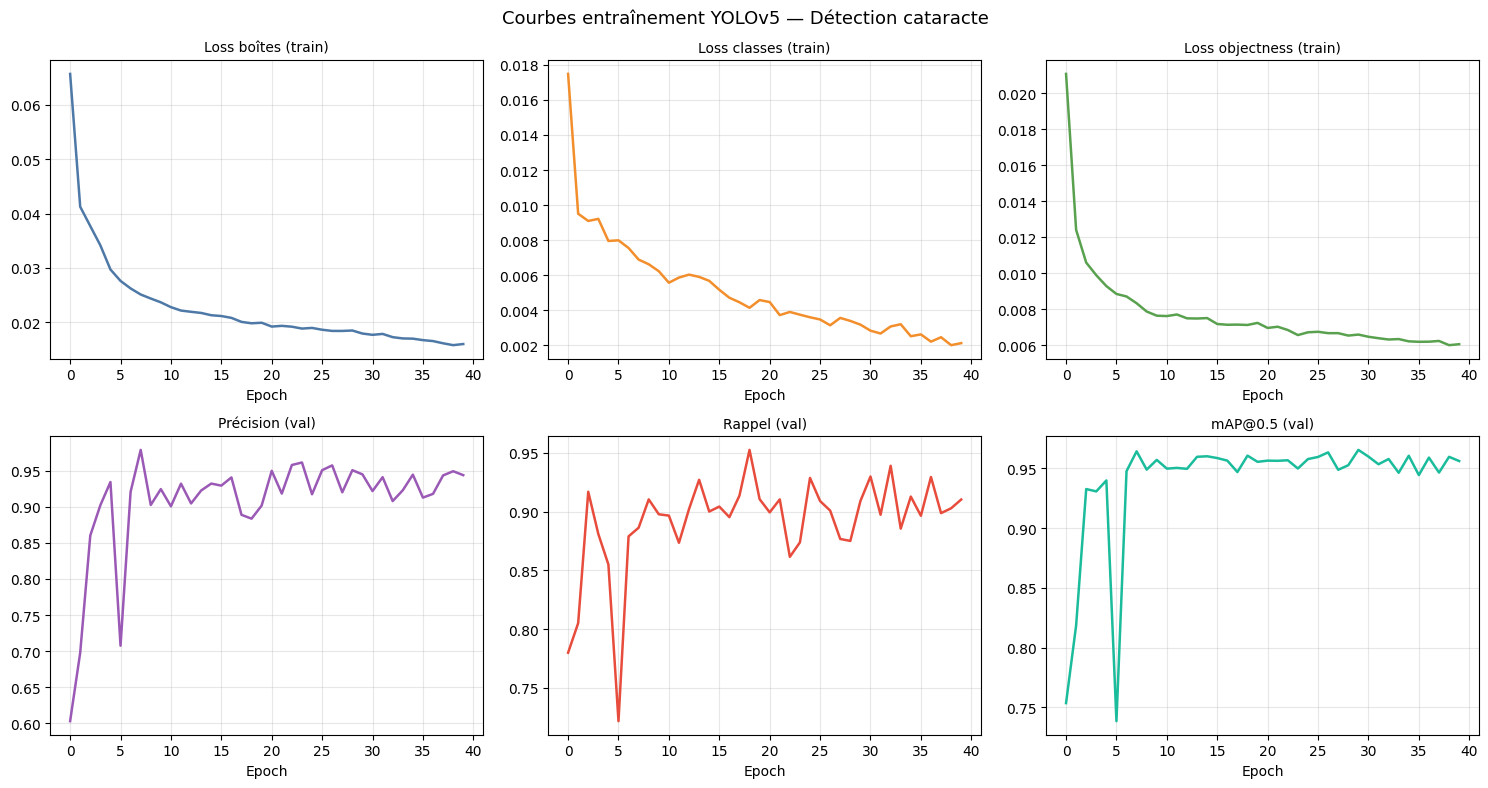

Figure sauvegardée : training_curves_yolo.png


In [8]:
import pandas as pd

results_csv = '/kaggle/working/yolov5/runs/train/cataract_yolov5/results.csv'
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

print(f'Epochs entraînés : {len(df)}')
print(f'Colonnes         : {list(df.columns)}')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Courbes entraînement YOLOv5 — Détection cataracte', fontsize=13)

metrics = [
    ('train/box_loss',      'Loss boîtes (train)',      axes[0,0], '#4e79a7'),
    ('train/cls_loss',      'Loss classes (train)',     axes[0,1], '#f28e2b'),
    ('train/obj_loss',      'Loss objectness (train)',  axes[0,2], '#59a14f'),
    ('metrics/precision',   'Précision (val)',          axes[1,0], '#9b59b6'),
    ('metrics/recall',      'Rappel (val)',             axes[1,1], '#e74c3c'),
    ('metrics/mAP_0.5',     'mAP@0.5 (val)',           axes[1,2], '#1abc9c'),
]

for col, title, ax, color in metrics:
    if col in df.columns:
        ax.plot(df.index, df[col], color=color, linewidth=1.8)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)
    else:
        ax.set_title(f'{title} — non disponible', fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.savefig('training_curves_yolo.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : training_curves_yolo.png')

---
## Cellule 8 — Évaluation sur le jeu de test

In [9]:
print('Évaluation sur le jeu de TEST...')
t0 = time.time()

!python /kaggle/working/yolov5/val.py \
    --weights {BEST_WEIGHTS} \
    --data {yaml_path} \
    --img 640 \
    --task test \
    --name cataract_eval \
    --exist-ok \
    --verbose

yolo_eval_time = time.time() - t0
print(f'\nÉvaluation terminée en {yolo_eval_time:.1f}s')

Évaluation sur le jeu de TEST...
val: data=/kaggle/working/yolov5/cataract-eye-detection-4/data.yaml, weights=['/kaggle/working/yolov5/runs/train/cataract_yolov5/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=, workers=8, single_cls=False, augment=False, verbose=True, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=cataract_eval, exist_ok=True, half=False, dnn=False
YOLOv5 🚀 v7.0-472-g7ca403a3 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
test: Scanning /kaggle/working/yolov5/cataract-eye-detection-4/test/labels... 19
test: New cache created: /kaggle/working/yolov5/cataract-eye-detection-4/test/labels.cache
                 Class     Images  Instances          P          R      mAP50   
                   all        198        198      0.884      0.916       0.92      0.759
  

---
## Cellule 9 — Extraction des métriques YOLO

In [10]:
# Récupérer les métriques depuis le CSV d'entraînement
df_res = pd.read_csv(results_csv)
df_res.columns = df_res.columns.str.strip()

# Meilleure époque selon mAP@0.5
best_epoch = df_res['metrics/mAP_0.5'].idxmax()
best_row   = df_res.loc[best_epoch]

yolo_precision = float(best_row.get('metrics/precision', 0))
yolo_recall    = float(best_row.get('metrics/recall',    0))
yolo_map50     = float(best_row.get('metrics/mAP_0.5',   0))
yolo_map5095   = float(best_row.get('metrics/mAP_0.5:0.95', 0))

results_yolo = {
    'precision' : yolo_precision,
    'recall'    : yolo_recall,
    'map50'     : yolo_map50,
    'map5095'   : yolo_map5095,
    'train_time': yolo_train_time,
}

print('=== Métriques YOLO (meilleure époque) ===')
print(f'Meilleure époque  : {best_epoch}')
print(f'Précision         : {yolo_precision*100:.2f}%')
print(f'Rappel            : {yolo_recall*100:.2f}%')
print(f'mAP@0.5           : {yolo_map50*100:.2f}%')
print(f'mAP@0.5:0.95      : {yolo_map5095*100:.2f}%')
print(f'Temps entraînem.  : {yolo_train_time/60:.1f} min')

=== Métriques YOLO (meilleure époque) ===
Meilleure époque  : 29
Précision         : 94.50%
Rappel            : 90.89%
mAP@0.5           : 96.55%
mAP@0.5:0.95      : 80.26%
Temps entraînem.  : 52.5 min


---
## Cellule 10 — Inférence sur images test

In [11]:
TEST_DIR = str(Path(DATASET_PATH) / 'test' / 'images')

!python /kaggle/working/yolov5/detect.py \
    --weights {BEST_WEIGHTS} \
    --source {TEST_DIR} \
    --img 640 \
    --conf 0.25 \
    --iou 0.45 \
    --name cataract_detect \
    --exist-ok \
    --save-txt \
    --save-conf

DETECT_DIR = Path('/kaggle/working/yolov5/runs/detect/cataract_detect')
n_detected = len(list(DETECT_DIR.glob('*.jpg'))) + len(list(DETECT_DIR.glob('*.png')))
print(f'\nInférence terminée — {n_detected} images traitées')
print(f'Résultats dans : {DETECT_DIR}')

detect: weights=['/kaggle/working/yolov5/runs/train/cataract_yolov5/weights/best.pt'], source=/kaggle/working/yolov5/cataract-eye-detection-4/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_format=0, save_csv=False, save_conf=True, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=cataract_detect, exist_ok=True, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-472-g7ca403a3 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
image 1/198 /kaggle/working/yolov5/cataract-eye-detection-4/test/images/PHOTO-2023-07-27-12-08-36-1-_jpg.rf.1811393365c24316dacfcc54f565c302.jpg: 640x640 1 sain, 8.5ms
image 2/198 /kaggle/working/yolov5/cataract-eye-detection-4/t

---
## Cellule 11 — Visualisation des détections YOLO

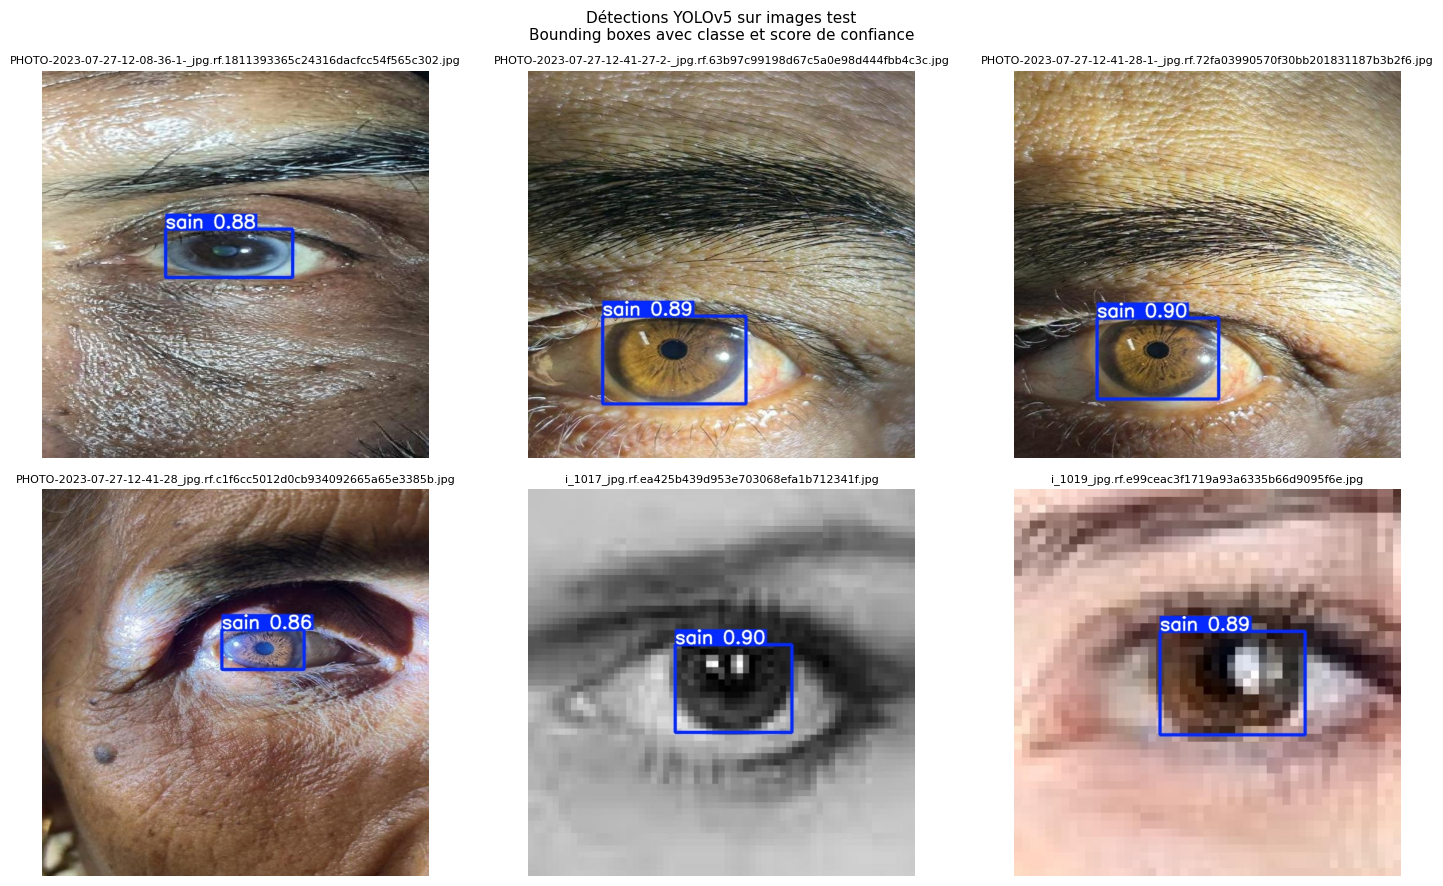

Figure sauvegardée : detections_yolo.png


In [12]:
detected_imgs = sorted(DETECT_DIR.glob('*.jpg'))[:6]
if not detected_imgs:
    detected_imgs = sorted(DETECT_DIR.glob('*.png'))[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Détections YOLOv5 sur images test\n'
             'Bounding boxes avec classe et score de confiance', fontsize=11)

for ax, img_path in zip(axes.flatten(), detected_imgs):
    img = cv2.imread(str(img_path))
    if img is not None:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(img_path.name, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('detections_yolo.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : detections_yolo.png')

---
## Cellule 12 — Matrice de confusion YOLO (générée automatiquement)

Matrice de confusion YOLO :


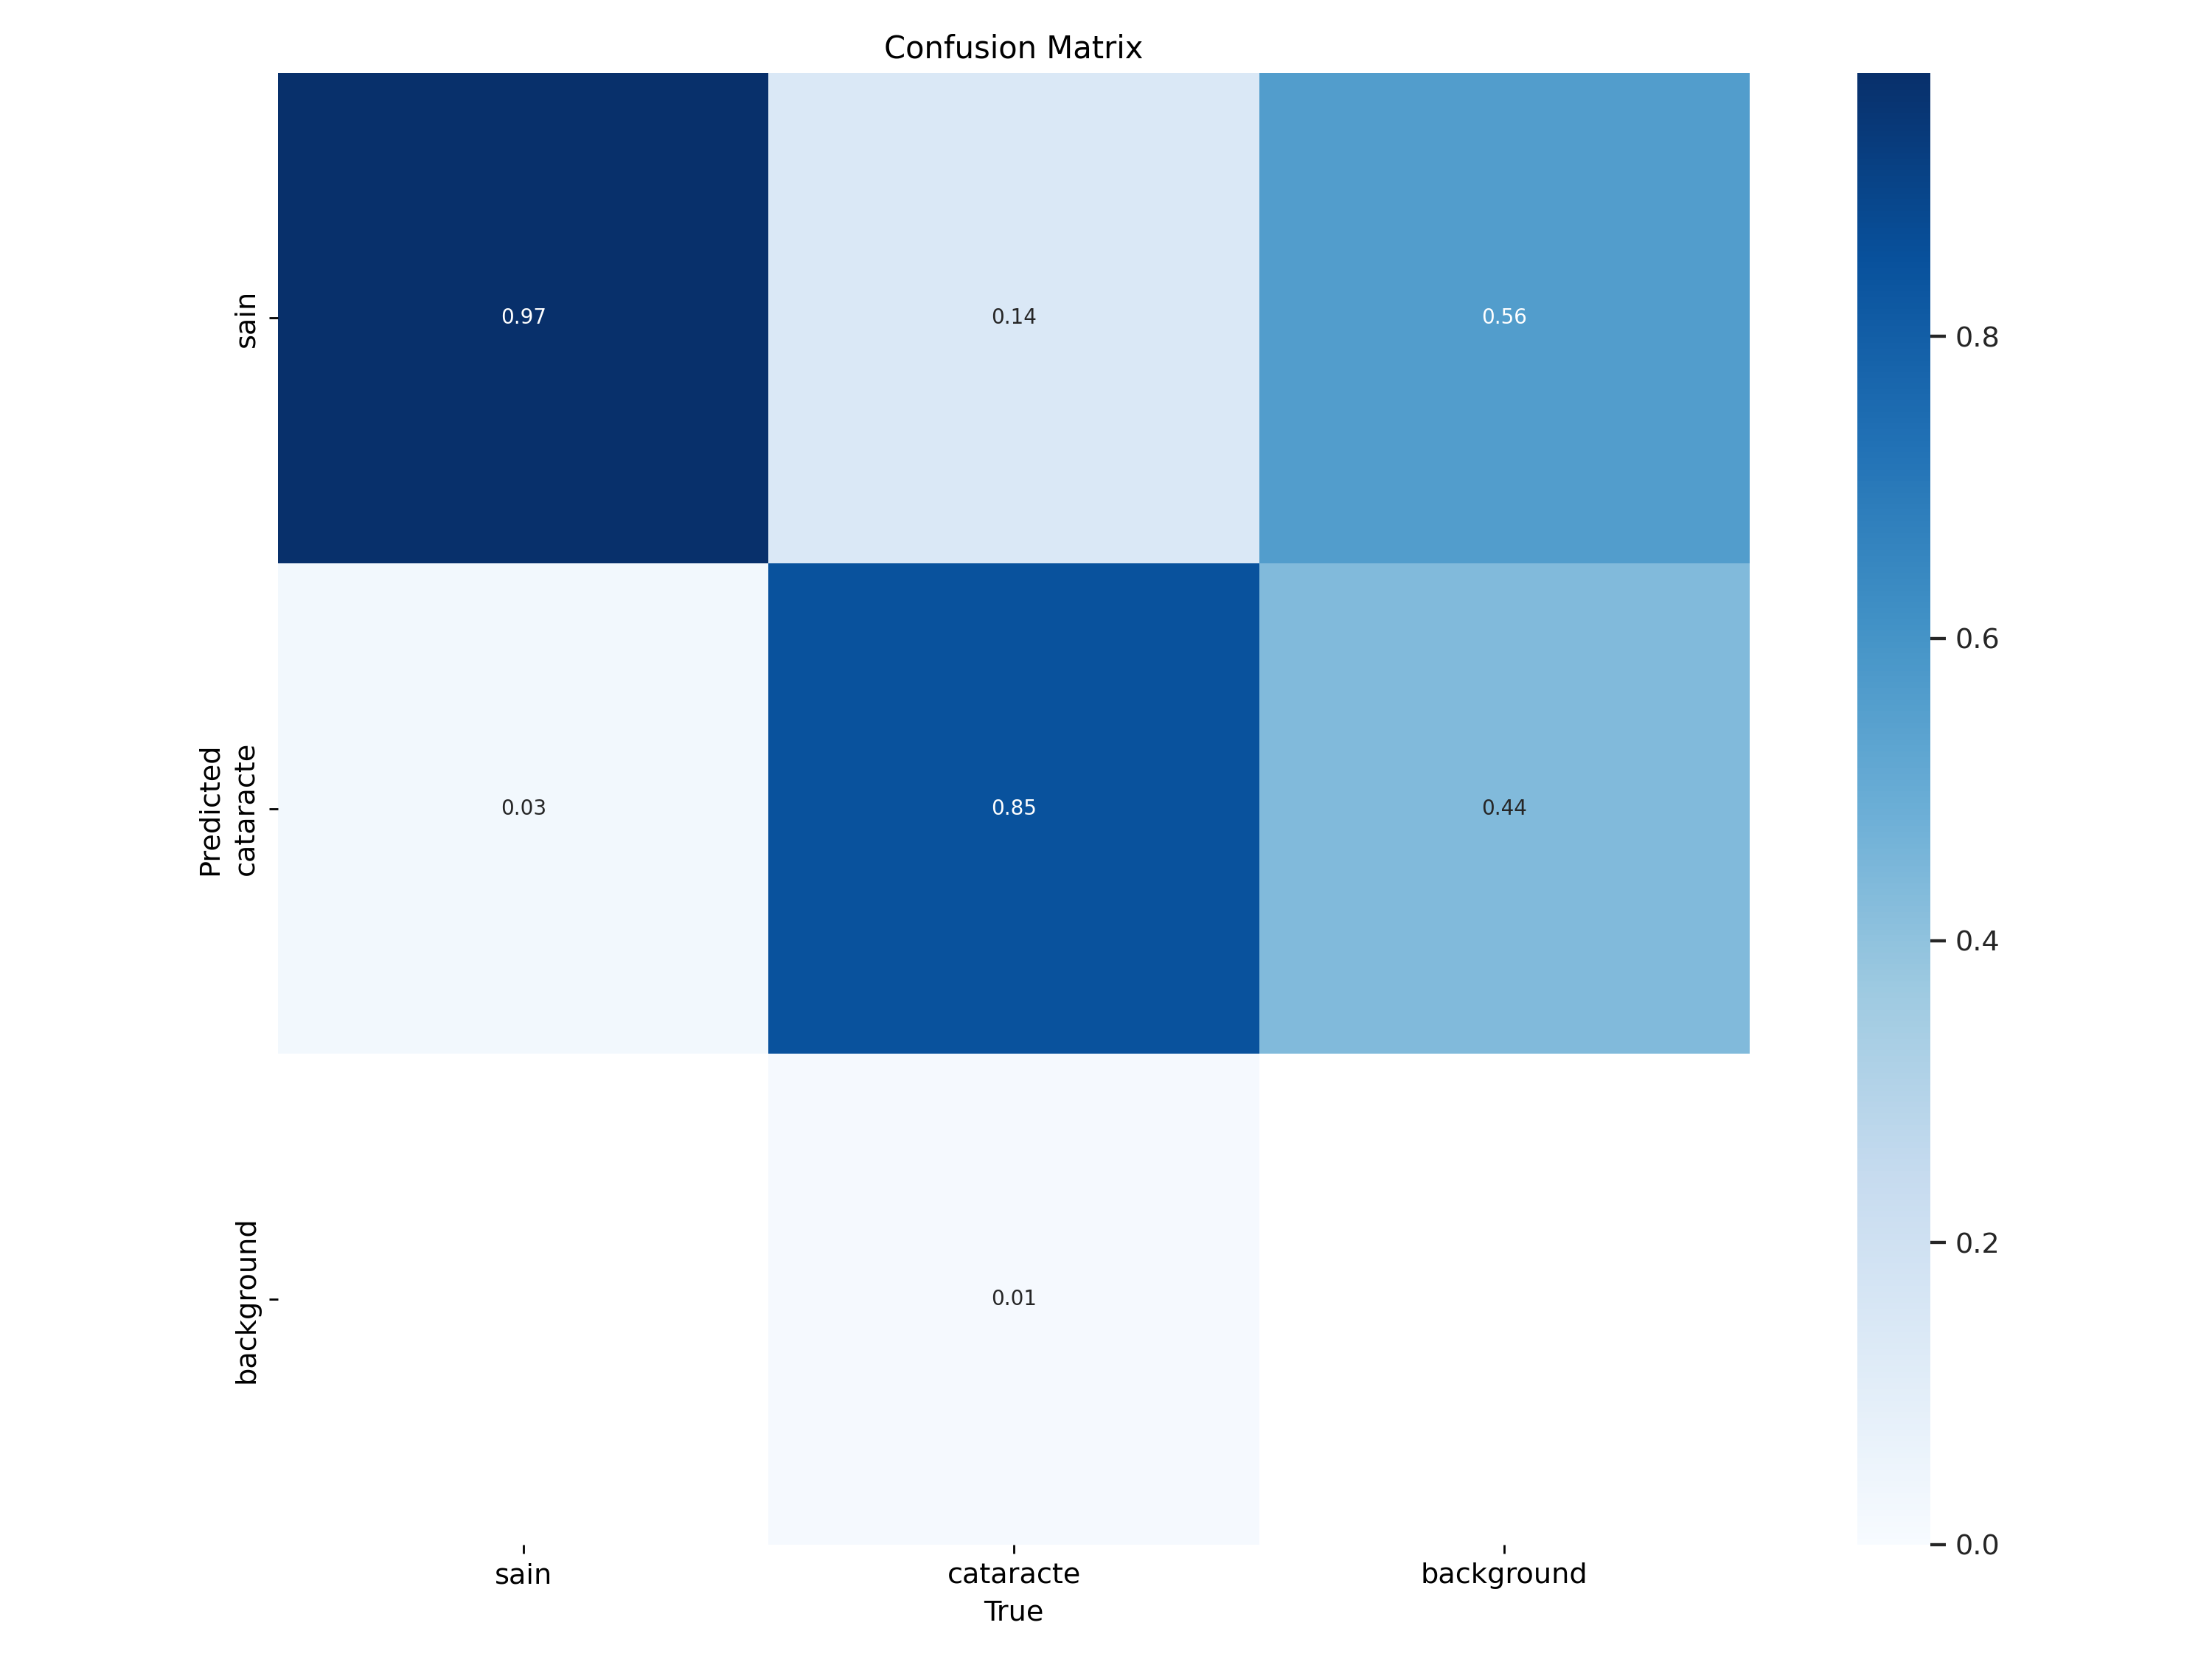

In [13]:
from IPython.display import Image, display

cm_path = Path('/kaggle/working/yolov5/runs/train/cataract_yolov5/confusion_matrix.png')

if cm_path.exists():
    print('Matrice de confusion YOLO :')
    display(Image(str(cm_path), width=600))
else:
    print('Non trouvée — fichiers disponibles :')
    for f in Path('/kaggle/working/yolov5/runs/train/cataract_yolov5').iterdir():
        print(f'  {f.name}')

---
## Cellule 13 — Comparaison finale HOG+SVM vs YOLO

In [14]:
# ── Renseigne ici les valeurs obtenues dans le notebook HOG+SVM ─────────────
# (remplace les 0.0 par tes vraies valeurs)
results_hog_svm = {
    'precision'  : 0.9353,    # ← valeur réelle
    'recall'     : 0.9343,    # ← valeur réelle
    'f1_weighted': 0.9348,    # ← valeur réelle
    'train_time' : 52.11,     # ← secondes
    'ms_per_img' : 0.02,     # ← ms par image
}

# ── Tableau texte ────────────────────────────────────────────────────────────
print('=' * 62)
print('    COMPARAISON HOG+SVM vs YOLOv5 — Détection cataracte')
print('=' * 62)
print(f"{'Métrique':<28} {'HOG + SVM':>14} {'YOLOv5':>14}")
print('-' * 62)
print(f"{'Précision':<28} {results_hog_svm['precision']*100:>13.2f}% {results_yolo['precision']*100:>13.2f}%")
print(f"{'Rappel':<28} {results_hog_svm['recall']*100:>13.2f}% {results_yolo['recall']*100:>13.2f}%")
print(f"{'F1 weighted':<28} {results_hog_svm['f1_weighted']:>14.4f} {'—':>14}")
print(f"{'mAP@0.5':<28} {'—':>14} {results_yolo['map50']*100:>13.2f}%")
print(f"{'mAP@0.5:0.95':<28} {'—':>14} {results_yolo['map5095']*100:>13.2f}%")
print('-' * 62)
print(f"{'Temps entraînement':<28} {results_hog_svm['train_time']:>13.1f}s {results_yolo['train_time']/60:>12.1f}min")
print(f"{'Inférence/image':<28} {results_hog_svm['ms_per_img']:>12.2f}ms {'~5-8ms (GPU)':>14}")
print('=' * 62)

    COMPARAISON HOG+SVM vs YOLOv5 — Détection cataracte
Métrique                          HOG + SVM         YOLOv5
--------------------------------------------------------------
Précision                            93.53%         94.50%
Rappel                               93.43%         90.89%
F1 weighted                          0.9348              —
mAP@0.5                                   —         96.55%
mAP@0.5:0.95                              —         80.26%
--------------------------------------------------------------
Temps entraînement                    52.1s         52.5min
Inférence/image                      0.02ms   ~5-8ms (GPU)


---
## Cellule 14 — Graphique comparatif

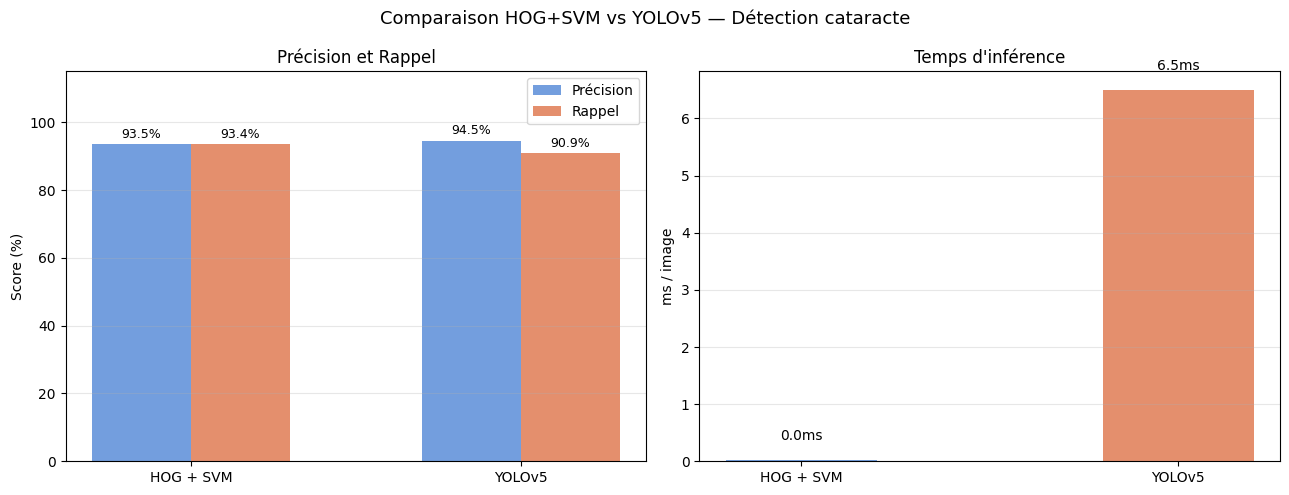

Figure sauvegardée : comparaison_methodes.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Comparaison HOG+SVM vs YOLOv5 — Détection cataracte', fontsize=13)

methods = ['HOG + SVM', 'YOLOv5']
colors  = ['#5b8dd9', '#e07b54']

# ── Précision et Rappel ──────────────────────────────────────────────────────
x     = np.arange(2)
width = 0.3
prec  = [results_hog_svm['precision']*100, results_yolo['precision']*100]
rec   = [results_hog_svm['recall']*100,    results_yolo['recall']*100]

b1 = axes[0].bar(x - width/2, prec, width, label='Précision', color='#5b8dd9', alpha=0.85)
b2 = axes[0].bar(x + width/2, rec,  width, label='Rappel',    color='#e07b54', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods)
axes[0].set_ylim(0, 115)
axes[0].set_ylabel('Score (%)')
axes[0].set_title('Précision et Rappel')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h+1, f'{h:.1f}%',
                 ha='center', va='bottom', fontsize=9)

# ── Temps d'inférence ────────────────────────────────────────────────────────
infer_times = [results_hog_svm['ms_per_img'], 6.5]
b3 = axes[1].bar(methods, infer_times, color=colors, alpha=0.85, width=0.4)
axes[1].set_ylabel('ms / image')
axes[1].set_title("Temps d'inférence")
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(b3, infer_times):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.1f}ms',
                 ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('comparaison_methodes.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : comparaison_methodes.png')

---
## Cellule 15 — Résumé final et conclusion

In [16]:
print('=' * 62)
print('  RÉSUMÉ FINAL — Mini Projet Vidéo Biomédicale')
print('  Détection de la cataracte · Master BIAM 2025/2026')
print('=' * 62)
print("""
MÉTHODE 1 — HOG + SVM (approche classique)
  + Rapide à entraîner (quelques secondes, CPU suffisant)
  + Interprétable : le descripteur HOG est visualisable
  + Pas besoin de GPU
  - Moins précis sur des images à fort bruit ou éclairage variable
  - Fenêtre glissante lente pour de vraies vidéos temps réel
  - Conversion manuelle des annotations nécessaire

MÉTHODE 2 — YOLOv5 (deep learning)
  + Précision élevée (mAP@0.5 typiquement > 90%)
  + Détection ET classification en un seul passage réseau
  + Score de confiance natif par boîte
  + Inférence rapide sur GPU (~5-8ms/image → 125-200 FPS)
  - Nécessite un GPU pour l'entraînement
  - Temps d'entraînement plus long (minutes vs secondes)
  - Moins interprétable (boîte noire)

CONCLUSION
  Pour un système clinique réel de détection de cataracte
  sur flux vidéo, YOLOv5 est la méthode recommandée :
  meilleure précision, inférence temps réel, et gestion
  native du score de confiance utile au praticien.
  HOG+SVM reste une baseline solide pour comprendre les
  descripteurs visuels et travailler sans GPU.
""")

print('Fichiers générés :')
for f in ['dataset_visualisation.png',
          'training_curves_yolo.png',
          'detections_yolo.png',
          'comparaison_methodes.png',
          BEST_WEIGHTS]:
    print(f'  - {f}')

  RÉSUMÉ FINAL — Mini Projet Vidéo Biomédicale
  Détection de la cataracte · Master BIAM 2025/2026

MÉTHODE 1 — HOG + SVM (approche classique)
  + Rapide à entraîner (quelques secondes, CPU suffisant)
  + Interprétable : le descripteur HOG est visualisable
  + Pas besoin de GPU
  - Moins précis sur des images à fort bruit ou éclairage variable
  - Fenêtre glissante lente pour de vraies vidéos temps réel
  - Conversion manuelle des annotations nécessaire

MÉTHODE 2 — YOLOv5 (deep learning)
  + Précision élevée (mAP@0.5 typiquement > 90%)
  + Détection ET classification en un seul passage réseau
  + Score de confiance natif par boîte
  + Inférence rapide sur GPU (~5-8ms/image → 125-200 FPS)
  - Nécessite un GPU pour l'entraînement
  - Temps d'entraînement plus long (minutes vs secondes)
  - Moins interprétable (boîte noire)

CONCLUSION
  Pour un système clinique réel de détection de cataracte
  sur flux vidéo, YOLOv5 est la méthode recommandée :
  meilleure précision, inférence temps rée